# 03 — Voiceprint Verification Model

Trains a speaker-identification classifier on MFCC / spectral roll-off /
energy features extracted from each member's voice commands
("Yes, approve", "Confirm transaction") and their pitch-shift /
time-stretch / background-noise augmentations.

Run `python process_audio.py` first to (re)generate `data/audio_features.csv`
from `audio/<person>/*.wav`.


## 0. Imports & config


In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import LabelEncoder

DATA_PATH = Path("../data/audio_features.csv")
MODEL_PATH = Path("../models/voice_verification_model.pkl")
ENCODER_PATH = Path("../models/voice_label_encoder.pkl")
REPORT_DIR = Path("../reports")
REPORT_PATH = REPORT_DIR / "voice_verification_evaluation.md"
CM_PATH = REPORT_DIR / "audio_confusion_matrix.png"
TARGET = "person_id"
RANDOM_STATE = 42


## 1. Load & validate


In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATA_PATH.resolve()}. Run `python process_audio.py` first."
    )

df = pd.read_csv(DATA_PATH, encoding="utf-8", sep=",")
print(f"[OK] Loaded {DATA_PATH.name}  shape={df.shape}")

required = ["customer_id", "person_id", "phrase", "augmentation"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"{DATA_PATH.name} missing columns: {missing}")

print("Samples per person:")
print(df[TARGET].value_counts())
print("\nSamples per augmentation:")
print(df["augmentation"].value_counts())
print("\nMissing values:", int(df.isnull().sum().sum()))


[OK] Loaded audio_features.csv  shape=(42, 36)
Samples per person:
person_id
person1    14
person2    14
person3    14
Name: count, dtype: int64

Samples per augmentation:
augmentation
original        6
pitch_up        6
pitch_down      6
stretch_fast    6
stretch_slow    6
noise_low       6
noise_high      6
Name: count, dtype: int64

Missing values: 0


## 2. Features / target


In [3]:
meta_cols = ["customer_id", "person_id", "phrase", "text", "augmentation", "file"]
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].copy()
y_raw = df[TARGET].astype(str)

label = LabelEncoder()
y = label.fit_transform(y_raw)

assert X.isnull().sum().sum() == 0
print(f"Feature columns ({len(feature_cols)}):", feature_cols)
print("Classes (voiceprints):", list(label.classes_))


Feature columns (30): ['mfcc1_mean', 'mfcc1_std', 'mfcc2_mean', 'mfcc2_std', 'mfcc3_mean', 'mfcc3_std', 'mfcc4_mean', 'mfcc4_std', 'mfcc5_mean', 'mfcc5_std', 'mfcc6_mean', 'mfcc6_std', 'mfcc7_mean', 'mfcc7_std', 'mfcc8_mean', 'mfcc8_std', 'mfcc9_mean', 'mfcc9_std', 'mfcc10_mean', 'mfcc10_std', 'mfcc11_mean', 'mfcc11_std', 'mfcc12_mean', 'mfcc12_std', 'mfcc13_mean', 'mfcc13_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'energy_mean', 'energy_std']
Classes (voiceprints): ['person1', 'person2', 'person3']


## 3. Train / test split, train classifier


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Small, high-dimensional feature set from a handful of speakers ⇒
# a modest, regularized forest generalizes better than a deep one.
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
model.fit(X_train, y_train)
print("Train size:", len(X_train), "Test size:", len(X_test))


Train size: 31 Test size: 11


## 4. Holdout evaluation — Accuracy, F1, Loss


Accuracy:      0.7273
F1 (macro):    0.7302
F1 (weighted): 0.7359
Loss (log_loss): 0.6844

              precision    recall  f1-score   support

     person1       0.67      0.67      0.67         3
     person2       0.60      0.75      0.67         4
     person3       1.00      0.75      0.86         4

    accuracy                           0.73        11
   macro avg       0.76      0.72      0.73        11
weighted avg       0.76      0.73      0.74        11



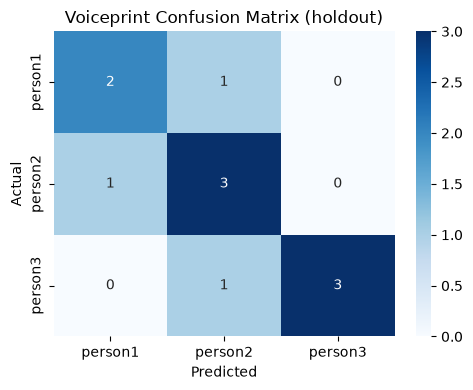

Saved confusion matrix -> /home/wiseking/Documents/Formative-2---Data-Preprocessing/multimodal-authentication/reports/audio_confusion_matrix.png


In [5]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
labels_idx = list(range(len(label.classes_)))

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro", labels=labels_idx, zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average="weighted", labels=labels_idx, zero_division=0)

loss_value = None
loss_note = ""
try:
    loss_value = float(log_loss(y_test, y_proba, labels=labels_idx))
    if np.isnan(loss_value) or np.isinf(loss_value):
        raise ValueError("Log loss is undefined (NaN/Inf).")
except ValueError as exc:
    loss_value = None
    loss_note = f"Log loss could not be computed: {exc}."

clf_report = classification_report(
    y_test,
    y_pred,
    labels=labels_idx,
    target_names=label.classes_,
    zero_division=0,
)

print(f"Accuracy:      {accuracy:.4f}")
print(f"F1 (macro):    {f1_macro:.4f}")
print(f"F1 (weighted): {f1_weighted:.4f}")
if loss_value is not None:
    print(f"Loss (log_loss): {loss_value:.4f}")
else:
    print(loss_note or "Loss (log_loss): N/A")
print()
print(clf_report)

cm = confusion_matrix(y_test, y_pred, labels=labels_idx)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label.classes_,
    yticklabels=label.classes_,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Voiceprint Confusion Matrix (holdout)")
plt.tight_layout()
REPORT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(CM_PATH, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved confusion matrix -> {CM_PATH.resolve()}")


## 5. Stratified K-Fold cross-validation

`n_splits=3` matches the number of voiceprint classes (one member per class).


In [6]:
n_splits = min(3, int(np.min(np.bincount(y))))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=False,
)

acc_scores = cv_results["test_accuracy"]
f1_scores = cv_results["test_f1_macro"]
print("Fold accuracy:", np.round(acc_scores, 4))
print(f"Mean accuracy: {acc_scores.mean():.4f}  std: {acc_scores.std():.4f}")
print("Fold F1-macro:", np.round(f1_scores, 4))
print(f"Mean F1-macro: {f1_scores.mean():.4f}  std: {f1_scores.std():.4f}")


Fold accuracy: [0.6429 0.7857 0.7143]
Mean accuracy: 0.7143  std: 0.0583
Fold F1-macro: [0.6633 0.7778 0.7   ]
Mean F1-macro: 0.7137  std: 0.0477


## 6. Feature importance


In [7]:
importances = (
    pd.Series(model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)
print(importances.head(20).to_string())


mfcc5_mean               0.122457
mfcc11_std               0.102295
mfcc9_mean               0.075809
mfcc10_std               0.065557
mfcc12_std               0.043632
mfcc2_std                0.042867
mfcc1_std                0.041992
spectral_rolloff_std     0.040781
mfcc2_mean               0.038028
energy_std               0.037010
mfcc9_std                0.033474
mfcc4_std                0.026401
mfcc12_mean              0.026354
mfcc3_mean               0.023893
mfcc13_mean              0.022733
mfcc6_std                0.021244
mfcc13_std               0.021225
mfcc1_mean               0.020100
spectral_rolloff_mean    0.019204
energy_mean              0.018522


## 7. Export evaluation report + persist model


In [8]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)


def _fmt(v):
    return f"{v:.4f}" if v is not None else "N/A"


loss_section = f"| Loss (log_loss) | {_fmt(loss_value)} |\n"
if loss_note:
    loss_section += f"\n> {loss_note}\n"

importance_md = "\n".join(
    f"| `{name}` | {val:.4f} |" for name, val in importances.head(20).items()
)

report = f"""# Voiceprint Verification — Evaluation Report

Generated by `notebooks/03_voice_verification.ipynb`.

## Dataset statistics

| Item | Value |
|------|-------|
| Source file | `{DATA_PATH.name}` |
| Rows (voice samples) | {len(df)} |
| Features used | {len(feature_cols)} |
| Voiceprint classes (members) | {len(label.classes_)} |
| Train / test size | {len(X_train)} / {len(X_test)} |
| Random state | {RANDOM_STATE} |

### Samples per voiceprint

```
{df[TARGET].value_counts().to_string()}
```

## Holdout metrics

| Metric | Value |
|--------|-------|
| Accuracy | {_fmt(accuracy)} |
| F1 (macro) | {_fmt(f1_macro)} |
| F1 (weighted) | {_fmt(f1_weighted)} |
{loss_section}

## Cross-validation (StratifiedKFold, n_splits={n_splits})

| Metric | Fold scores | Mean | Std |
|--------|-------------|------|-----|
| Accuracy | {np.round(acc_scores, 4).tolist()} | {acc_scores.mean():.4f} | {acc_scores.std():.4f} |
| F1 (macro) | {np.round(f1_scores, 4).tolist()} | {f1_scores.mean():.4f} | {f1_scores.std():.4f} |

## Classification report

```
{clf_report}
```

## Confusion matrix

![Confusion matrix](audio_confusion_matrix.png)

```
{pd.DataFrame(cm, index=label.classes_, columns=label.classes_).to_string()}
```

## Feature importance (top 20)

| Feature | Importance |
|---------|------------|
{importance_md}

## Notes

- Target is `person_id` (voiceprint identity), not `customer_id` — `audio_features.csv`
  uses its own `C0xx` customer IDs (see README limitations) until linked to tabular IDs.
- Each member contributes 2 phrases x 7 variants (original + pitch up/down +
  stretch fast/slow + noise low/high) = 14 samples.
- Small sample size ⇒ metrics are illustrative of the pipeline, not production-grade accuracy.
"""

REPORT_PATH.write_text(report, encoding="utf-8")
print(f"Saved evaluation report -> {REPORT_PATH.resolve()}")

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)
joblib.dump(label, ENCODER_PATH)
print(f"Saved model -> {MODEL_PATH.resolve()}")
print(f"Saved label encoder -> {ENCODER_PATH.resolve()}")


Saved evaluation report -> /home/wiseking/Documents/Formative-2---Data-Preprocessing/multimodal-authentication/reports/voice_verification_evaluation.md
Saved model -> /home/wiseking/Documents/Formative-2---Data-Preprocessing/multimodal-authentication/models/voice_verification_model.pkl
Saved label encoder -> /home/wiseking/Documents/Formative-2---Data-Preprocessing/multimodal-authentication/models/voice_label_encoder.pkl
